# Import Libraries

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import pairwise_distances
from scipy.spatial.distance import squareform, pdist
from itertools import combinations

from sympy.physics.quantum.tests.test_cartesian import px

# Data Collection

Dataset:
[Wave Energy Converters](https://archive.ics.uci.edu/dataset/494/wave+energy+converters)

In [50]:
adelaide_df = pd.read_csv('../data/raw/Adelaide_Data.csv', header=None)
perth_df = pd.read_csv('../data/raw/Perth_Data.csv', header=None)
sydney_df = pd.read_csv('../data/raw/Sydney_Data.csv', header=None)
tasmania_df = pd.read_csv('../data/raw/Tasmania_Data.csv', header=None)

In [51]:
adelaide_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71999 entries, 0 to 71998
Data columns (total 49 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       71999 non-null  float64
 1   1       71999 non-null  float64
 2   2       71999 non-null  float64
 3   3       71999 non-null  float64
 4   4       71999 non-null  float64
 5   5       71999 non-null  float64
 6   6       71999 non-null  float64
 7   7       71999 non-null  float64
 8   8       71999 non-null  float64
 9   9       71999 non-null  float64
 10  10      71999 non-null  float64
 11  11      71999 non-null  float64
 12  12      71999 non-null  float64
 13  13      71999 non-null  float64
 14  14      71999 non-null  float64
 15  15      71999 non-null  float64
 16  16      71999 non-null  float64
 17  17      71999 non-null  float64
 18  18      71999 non-null  float64
 19  19      71999 non-null  float64
 20  20      71999 non-null  float64
 21  21      71999 non-null  float64
 22

# Column Renaming

In [52]:
rename_cols = lambda col: (
    f'x{c + 1}' if (c := int(col)) < 16 else
    f'y{c % 16 + 1}' if c < 32 else
    f'p{c % 16 + 1}' if c < 48 else
    f'total_power'
)

adelaide_df.rename(columns=rename_cols, inplace=True)
perth_df.rename(columns=rename_cols, inplace=True)
sydney_df.rename(columns=rename_cols, inplace=True)
tasmania_df.rename(columns=rename_cols, inplace=True)

adelaide_df['location'] = 'Adelaide'
perth_df['location'] = 'Perth'
sydney_df['location'] = 'Sydney'
tasmania_df['location'] = 'Tasmania'

In [53]:
adelaide_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71999 entries, 0 to 71998
Data columns (total 50 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   x1           71999 non-null  float64
 1   x2           71999 non-null  float64
 2   x3           71999 non-null  float64
 3   x4           71999 non-null  float64
 4   x5           71999 non-null  float64
 5   x6           71999 non-null  float64
 6   x7           71999 non-null  float64
 7   x8           71999 non-null  float64
 8   x9           71999 non-null  float64
 9   x10          71999 non-null  float64
 10  x11          71999 non-null  float64
 11  x12          71999 non-null  float64
 12  x13          71999 non-null  float64
 13  x14          71999 non-null  float64
 14  x15          71999 non-null  float64
 15  x16          71999 non-null  float64
 16  y1           71999 non-null  float64
 17  y2           71999 non-null  float64
 18  y3           71999 non-null  float64
 19  y4  

In [11]:
adelaide_df.describe().T

,count,mean,std,min,25%,50%,75%,max
x1,287999.0,3.033614e+02,1.901123e+02,0.000000e+00,1.258082e+02,3.259884e+02,4.808997e+02,5.660000e+02
x2,287999.0,2.888290e+02,1.861985e+02,0.000000e+00,1.182549e+02,2.955663e+02,4.591079e+02,5.660000e+02
x3,287999.0,2.854713e+02,1.914871e+02,0.000000e+00,1.014796e+02,2.953504e+02,4.618632e+02,5.660000e+02
x4,287999.0,2.702581e+02,1.901820e+02,0.000000e+00,9.172270e+01,2.612055e+02,4.443037e+02,5.660000e+02
x5,287999.0,3.083923e+02,1.837539e+02,0.000000e+00,1.440969e+02,3.247872e+02,4.767441e+02,5.660000e+02
x6,287999.0,2.590163e+02,1.955984e+02,0.000000e+00,7.033230e+01,2.385402e+02,4.455955e+02,5.660000e+02
x7,287999.0,2.676938e+02,1.884894e+02,0.000000e+00,9.259815e+01,2.509009e+02,4.442544e+02,5.660000e+02
x8,287999.0,2.814400e+02,1.828069e+02,0.000000e+00,1.168579e+02,2.807679e+02,4.485785e+02,5.660000e+02
x9,287999.0,2.786783e+02,1.864688e+02,0.000000e+00,1.087951e+02,2.750159e+02,4.526396e+02,5.660000e+02
x10,287999.0,2.793135e+02,1.883202e+02,0.000000e+00,1.050472e+02,2.798851e+02,4.528669e+02,5.660000e+02


# Data Split

In [54]:
adelaide_X = adelaide_df.drop('total_power', axis=1)
adelaide_y = adelaide_df['total_power']

perth_X = perth_df.drop('total_power', axis=1)
perth_y = perth_df['total_power']

sydney_X = sydney_df.drop('total_power', axis=1)
sydney_y = sydney_df['total_power']

tasmania_X = tasmania_df.drop('total_power', axis=1)
tasmania_y = tasmania_df['total_power']

In [55]:
aX_train, aX_temp, ay_train, ay_temp = train_test_split(adelaide_X, adelaide_y, test_size=0.2, random_state=42)
aX_val, aX_test, ay_val, ay_test = train_test_split(aX_temp, ay_temp, test_size=0.5, random_state=42)

pX_train, pX_temp, py_train, py_temp = train_test_split(perth_X, perth_y, test_size=0.2, random_state=42)
pX_val, pX_test, py_val, py_test = train_test_split(pX_temp, py_temp, test_size=0.5, random_state=42)

sX_train, sX_temp, sy_train, sy_temp = train_test_split(sydney_X, sydney_y, test_size=0.2, random_state=42)
sX_val, sX_test, sy_val, sy_test = train_test_split(sX_temp, sy_temp, test_size=0.5, random_state=42)

tX_train, tX_temp, ty_train, ty_temp = train_test_split(tasmania_X, tasmania_y, test_size=0.2, random_state=42)
tX_val, tX_test, ty_val, ty_test = train_test_split(tX_temp, ty_temp, test_size=0.5, random_state=42)


In [56]:
aX_train.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,p8,p9,p10,p11,p12,p13,p14,p15,p16,location
24522,154.8014,178.9767,188.7277,112.4635,459.9398,436.2728,244.7225,289.9836,20.8115,272.0506,...,75780.2988,59906.0031,75902.0351,97911.8321,97208.2185,85226.7910,97628.5088,93848.4519,70835.4696,Adelaide
71414,46.1547,464.5809,289.8600,86.9150,0.0000,197.5313,245.4543,566.0000,222.4804,387.0030,...,98622.0803,97768.3534,87290.3207,95896.5378,98727.3899,99215.7918,92871.4534,97493.7457,74627.2922,Adelaide
69688,9.8898,75.7299,467.4424,226.6227,59.5927,473.5070,478.0937,362.7268,45.1918,520.5394,...,88488.1307,95283.0322,100292.8631,72028.7124,77753.2848,94510.4759,71551.3884,80451.9392,98304.2668,Adelaide
33288,388.5926,146.3289,565.6854,218.4761,196.3975,0.0000,77.1750,396.9160,384.9837,423.7004,...,95449.2751,97833.0605,99497.1199,60117.0504,83317.9370,73854.5490,70582.4661,88030.5572,89895.6431,Adelaide
13931,95.8408,346.8732,66.8906,325.9123,0.0000,565.6854,313.9661,372.6658,565.6854,0.0000,...,90249.1816,96870.7308,97497.4993,82105.1651,66302.5499,92316.3642,96693.2851,86195.1589,73608.6604,Adelaide


In [57]:
aX_train.describe()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,p7,p8,p9,p10,p11,p12,p13,p14,p15,p16
count,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,...,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000
mean,281.602658,280.054631,294.319234,264.064020,289.946144,246.386428,253.012109,322.063288,280.240422,288.772326,...,87647.718501,88415.557751,88301.048842,87559.555568,88656.522323,88433.177625,87180.793615,87676.976592,89206.458302,88462.855002
std,178.306498,177.899714,182.087501,194.924274,179.927451,191.486296,178.458494,178.508120,190.418254,178.164412,...,10327.399636,10111.102466,10159.876750,10169.751177,10512.998293,10502.939672,10559.380468,10426.235044,10452.878254,10557.780629
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,48284.268200,51444.747000,51304.021600,49409.891500,49814.045300,51660.410600,50206.641300,51141.599700,50628.552800,47273.983600
25%,117.444850,117.385050,116.564400,76.920500,122.316250,67.298100,89.560900,166.021700,102.755750,126.953450,...,80208.828500,81443.931550,81077.615250,80550.049350,80783.659600,80832.255600,79088.804900,79889.212250,81603.997950,80376.239900
50%,282.913500,282.139600,315.998200,247.931900,285.837700,213.194400,234.876500,355.605500,266.076400,289.072000,...,88770.487600,90248.823200,90017.973000,88055.551600,90984.624100,89955.417100,87641.114700,88954.361800,92168.847400,90636.192000
75%,437.605350,444.720100,455.280350,444.977350,460.309000,433.193700,409.727100,481.046050,463.800650,448.641850,...,97446.677500,97413.806300,97439.124150,97333.861000,97808.094250,97728.674750,97471.294050,97494.511250,98085.310350,97662.710450
max,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,566.000000,...,104688.834500,105005.183000,105526.299600,105420.107400,105395.279300,105539.986600,105447.760000,105301.202500,104602.318800,105390.327100


# Check for rows with 0 as value for any column

In [58]:
aX_train[aX_train.eq(0).any(axis=1)]

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,p8,p9,p10,p11,p12,p13,p14,p15,p16,location
71414,46.1547,464.5809,289.8600,86.9150,0.0000,197.5313,245.4543,566.0000,222.4804,387.0030,...,98622.0803,97768.3534,87290.3207,95896.5378,98727.3899,99215.7918,92871.4534,97493.7457,74627.2922,Adelaide
33288,388.5926,146.3289,565.6854,218.4761,196.3975,0.0000,77.1750,396.9160,384.9837,423.7004,...,95449.2751,97833.0605,99497.1199,60117.0504,83317.9370,73854.5490,70582.4661,88030.5572,89895.6431,Adelaide
13931,95.8408,346.8732,66.8906,325.9123,0.0000,565.6854,313.9661,372.6658,565.6854,0.0000,...,90249.1816,96870.7308,97497.4993,82105.1651,66302.5499,92316.3642,96693.2851,86195.1589,73608.6604,Adelaide
32323,173.5290,217.9519,416.4320,431.4625,371.4065,200.3255,361.0872,504.5889,232.3893,350.2745,...,97350.6053,65608.7061,72730.9126,98490.2175,80547.8384,74771.4693,97216.4124,97837.4014,89444.7938,Adelaide
21449,410.2394,431.5388,565.6854,462.2370,461.4937,153.2398,514.8394,149.8316,0.0000,0.0000,...,94610.7753,79231.1862,90418.8658,85170.0851,97785.1714,83506.7243,97257.4628,77106.3473,78720.3620,Adelaide
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41090,319.1349,42.6673,452.8260,460.3482,351.5861,3.8234,107.7324,223.8258,450.4719,93.1551,...,91309.1288,94041.5939,70854.0379,97506.2861,92893.6816,76613.3411,81139.4693,85622.7765,97295.2105,Adelaide
44131,527.1715,368.3705,566.0000,346.2755,456.1590,0.0000,62.8361,98.7492,29.3303,242.8582,...,73238.4922,66935.6882,88838.0812,96856.1478,98428.8675,83837.7956,95632.0988,97558.2135,85278.9639,Adelaide
37194,205.6815,54.2307,340.4474,131.1530,61.0711,207.1311,260.6237,407.4240,519.9664,566.0000,...,99296.0313,85929.9735,97727.5328,97473.3773,98706.6897,61852.7187,88462.0546,85684.0379,100961.7649,Adelaide
6265,0.0000,456.7805,237.8715,412.7716,130.1677,0.0000,140.8817,142.2173,276.7501,312.6430,...,70163.0250,71343.9049,97483.5425,85280.4805,77287.2749,82948.1871,65308.4712,84329.7785,100206.6834,Adelaide


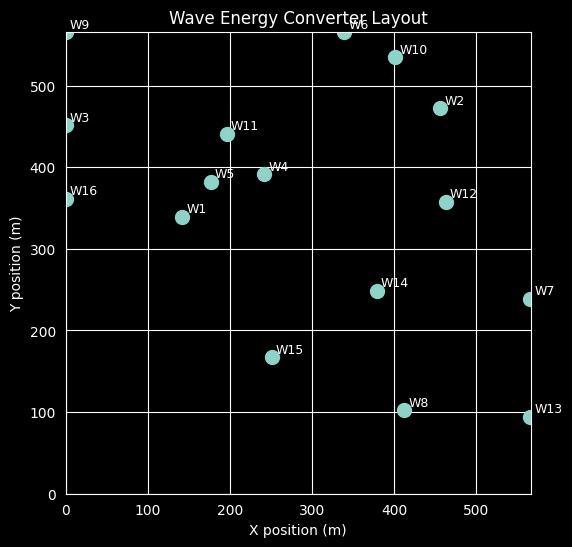

In [59]:
row = aX_train.iloc[69]  # pick one sample

x = row[0:16]
y = row[16:32]

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=100)

for i, (xi, yi) in enumerate(zip(x, y), start=1):
    plt.text(xi + 5, yi + 5, f"W{i}", fontsize=9)

plt.xlim(0, 566)
plt.ylim(0, 566)
plt.xlabel("X position (m)")
plt.ylabel("Y position (m)")
plt.title("Wave Energy Converter Layout")
plt.grid(True)
plt.show()

# Check for 0 value in 

In [60]:
aX_train.iloc[:, 32:].describe()

,p1,p2,p3,p4,p5,p6,p7,p8,p9,p10,p11,p12,p13,p14,p15,p16
count,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000,57599.000000
mean,87810.087880,87813.464879,88179.739226,88805.893935,87677.003097,88176.593528,87647.718501,88415.557751,88301.048842,87559.555568,88656.522323,88433.177625,87180.793615,87676.976592,89206.458302,88462.855002
std,10266.033263,10102.166768,10133.876722,10355.405354,10310.110032,10249.070888,10327.399636,10111.102466,10159.876750,10169.751177,10512.998293,10502.939672,10559.380468,10426.235044,10452.878254,10557.780629
min,51429.016700,52599.892600,49896.922800,52088.057200,51452.721500,49738.008300,48284.268200,51444.747000,51304.021600,49409.891500,49814.045300,51660.410600,50206.641300,51141.599700,50628.552800,47273.983600
25%,80240.739850,80504.359500,81072.867900,81452.037700,79950.835050,80470.214950,80208.828500,81443.931550,81077.615250,80550.049350,80783.659600,80832.255600,79088.804900,79889.212250,81603.997950,80376.239900
50%,89334.990700,88898.271600,89362.397500,90757.288000,88752.750100,89543.318700,88770.487600,90248.823200,90017.973000,88055.551600,90984.624100,89955.417100,87641.114700,88954.361800,92168.847400,90636.192000
75%,97378.205100,97338.581350,97459.233250,98044.315900,97376.763650,97693.315950,97446.677500,97413.806300,97439.124150,97333.861000,97808.094250,97728.674750,97471.294050,97494.511250,98085.310350,97662.710450
max,106057.325100,104848.662500,104727.716100,105378.457700,105018.350100,104684.920700,104688.834500,105005.183000,105526.299600,105420.107400,105395.279300,105539.986600,105447.760000,105301.202500,104602.318800,105390.327100


In [11]:
adc = adelaide_df.copy()

In [12]:
z_scores = (adc - adc.mean()) / adc.std()
adc = adc[(np.abs(z_scores) < 3).all(axis=1)]

In [13]:
coords = []

for i in range(1, 17):
    coords.append(adc[[f"x{i}", f"y{i}"]])

In [14]:
coords

[             x1        y1
 0      316.5855  180.9224
 1      530.3136  510.7784
 2       27.3967  102.5081
 3      346.1526  441.9194
 4      317.9144   94.6465
 ...         ...       ...
 71994    3.8797  218.8324
 71995   46.1547  529.1034
 71996   46.1547  529.1034
 71997   46.1547  529.1034
 71998   46.1547  529.1034
 
 [70551 rows x 2 columns],
              x2        y2
 0      223.9277  366.9186
 1       68.7031  564.9436
 2      399.0488  221.2811
 3       59.6375  560.6924
 4      551.8542  256.6874
 ...         ...       ...
 71994  404.4992  224.2999
 71995  487.8102   33.3026
 71996  487.8102   33.3026
 71997  487.8102   33.3026
 71998  487.8102   33.3026
 
 [70551 rows x 2 columns],
              x3        y3
 0      182.3434  200.9217
 1       31.5983  324.5823
 2      565.6854  303.2901
 3      226.2742    0.0000
 4      335.4745  434.6103
 ...         ...       ...
 71994  234.2780  508.6867
 71995  219.0245  123.4691
 71996  219.0245  123.4691
 71997  219.0245  123.46

# Encoding

### One Hot Encoding (for Neural Networks)

In [75]:
combined_X_train = pd.concat([aX_train, pX_train, sX_train, tX_train], ignore_index=True)
combined_X_val = pd.concat([aX_val, pX_val, sX_val, tX_val], ignore_index=True)
combined_X_test = pd.concat([aX_test, pX_test, sX_test, tX_test], ignore_index=True)

In [76]:
oh_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

combined_X_train_encoded = oh_encoder.fit_transform(combined_X_train[['location']])
combined_X_val_encoded = oh_encoder.transform(combined_X_val[['location']])
combined_X_test_encoded = oh_encoder.transform(combined_X_test[['location']])

In [77]:
oh_encoder.categories_

[array(['Adelaide', 'Perth', 'Sydney', 'Tasmania'], dtype=object)]

In [78]:
combined_X_train_nn = pd.concat([combined_X_train.drop('location', axis=1), pd.DataFrame(combined_X_train_encoded, columns=oh_encoder.get_feature_names_out(['location']))], axis=1)
combined_X_val_nn = pd.concat([combined_X_val.drop('location', axis=1), pd.DataFrame(combined_X_val_encoded, columns=oh_encoder.get_feature_names_out(['location']))], axis=1)
combined_X_test_nn = pd.concat([combined_X_test.drop('location', axis=1), pd.DataFrame(combined_X_test_encoded, columns=oh_encoder.get_feature_names_out(['location']))], axis=1)

### Label Encoding (for Trees)

In [79]:
label_encoder = LabelEncoder()

In [80]:
combined_X_train_tree = combined_X_train.copy().assign(location=lambda x: label_encoder.fit_transform(x['location']))
combined_X_val_tree = combined_X_val.copy().assign(location=lambda x: label_encoder.transform(x['location']))
combined_X_test_tree = combined_X_test.copy().assign(location=lambda x: label_encoder.transform(x['location']))

In [82]:
label_encoder.classes_

array(['Adelaide', 'Perth', 'Sydney', 'Tasmania'], dtype=object)

# WEC Distance

In [83]:
x_columns = slice(0, 16)
y_columns = slice(16, 32)

pairs = list(combinations(range(1, 17), 2))
column_names = [f"d_{i}_{j}" for i, j in pairs]

In [86]:
def compute_distances(df):
    x = df.iloc[:, x_columns].values
    y = df.iloc[:, y_columns].values
    coords = np.stack((x, y), axis=2)
    distances = np.array([pdist(sample, metric='euclidean') for sample in coords])
    return pd.DataFrame(distances, columns=column_names)

In [87]:
distance_train = compute_distances(combined_X_train_nn)
distance_val   = compute_distances(combined_X_val_nn)
distance_test  = compute_distances(combined_X_test_nn)

In [88]:
distance_train

,d_1_2,d_1_3,d_1_4,d_1_5,d_1_6,d_1_7,d_1_8,d_1_9,d_1_10,d_1_11,...,d_12_13,d_12_14,d_12_15,d_12_16,d_13_14,d_13_15,d_13_16,d_14_15,d_14_16,d_15_16
0,84.803774,333.013457,143.360421,305.142492,350.257719,356.834137,315.693862,388.596026,194.166826,532.549649,...,91.539923,373.148726,169.411184,474.829021,368.021000,91.904991,408.890100,441.528480,303.984742,424.250128
1,668.448919,448.447734,76.403504,59.089893,176.715677,355.677999,722.197341,177.869172,599.012495,278.631846,...,70.677116,244.777452,206.643993,322.513604,204.292311,137.164588,347.516323,216.393251,279.169252,447.132229
2,492.140532,461.483730,216.732901,406.212215,632.707087,592.243837,352.859733,57.915201,517.567905,390.708750,...,192.911243,249.737560,101.992218,307.930846,384.492183,218.138215,367.549666,341.888402,148.736616,409.899323
3,253.878727,202.807274,182.584984,355.407573,391.909121,323.548775,102.624194,192.146894,129.732973,436.058098,...,199.739062,277.360173,531.988118,315.054324,100.910451,378.902591,364.760371,404.003722,464.112442,434.639298
4,257.873217,426.604442,519.266382,97.184847,469.950341,398.246431,408.514549,474.614470,127.110284,266.535098,...,360.441208,515.716100,356.413541,162.093200,542.939668,148.108909,352.727121,666.733570,353.622900,411.708860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230394,195.111770,310.990762,360.127120,298.651640,403.639422,152.403518,403.833265,202.728480,279.956132,436.063276,...,273.213160,213.403185,400.641295,427.886347,452.515077,221.521643,177.002039,499.481970,570.535134,127.674100
230395,534.274378,211.799008,547.882985,422.672500,124.087100,130.056959,634.752092,592.427929,383.109736,441.648762,...,278.352987,305.953948,433.795383,359.943127,146.018199,155.885299,285.682198,229.758600,428.668243,337.865666
230396,307.236068,324.991599,160.007455,86.459289,128.601253,331.353958,324.662773,111.428347,275.471228,590.539578,...,305.757530,315.971122,226.139218,50.047553,111.378942,123.413702,277.967468,89.833208,274.662474,185.385537
230397,242.282658,243.541794,274.982610,316.237665,429.165667,140.443932,374.117193,436.232663,161.403730,431.565998,...,552.140606,390.218881,87.615810,424.012643,542.639039,492.671588,180.830882,312.219888,539.987177,386.219795


In [89]:
nn_X_train_full = pd.concat([combined_X_train_nn.reset_index(drop=True), distance_train], axis=1)
nn_X_val_full   = pd.concat([combined_X_val_nn.reset_index(drop=True), distance_val], axis=1)
nn_X_test_full  = pd.concat([combined_X_test_nn.reset_index(drop=True), distance_test], axis=1)

In [92]:
nn_X_train_full

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,...,d_12_13,d_12_14,d_12_15,d_12_16,d_13_14,d_13_15,d_13_16,d_14_15,d_14_16,d_15_16
0,154.8014,178.9767,188.7277,112.4635,459.9398,436.2728,244.7225,289.9836,20.8115,272.0506,...,91.539923,373.148726,169.411184,474.829021,368.021000,91.904991,408.890100,441.528480,303.984742,424.250128
1,46.1547,464.5809,289.8600,86.9150,0.0000,197.5313,245.4543,566.0000,222.4804,387.0030,...,70.677116,244.777452,206.643993,322.513604,204.292311,137.164588,347.516323,216.393251,279.169252,447.132229
2,9.8898,75.7299,467.4424,226.6227,59.5927,473.5070,478.0937,362.7268,45.1918,520.5394,...,192.911243,249.737560,101.992218,307.930846,384.492183,218.138215,367.549666,341.888402,148.736616,409.899323
3,388.5926,146.3289,565.6854,218.4761,196.3975,0.0000,77.1750,396.9160,384.9837,423.7004,...,199.739062,277.360173,531.988118,315.054324,100.910451,378.902591,364.760371,404.003722,464.112442,434.639298
4,95.8408,346.8732,66.8906,325.9123,0.0000,565.6854,313.9661,372.6658,565.6854,0.0000,...,360.441208,515.716100,356.413541,162.093200,542.939668,148.108909,352.727121,666.733570,353.622900,411.708860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230394,165.3849,143.0102,430.5333,486.7569,412.4500,566.0000,212.8853,148.5834,0.0000,422.6239,...,273.213160,213.403185,400.641295,427.886347,452.515077,221.521643,177.002039,499.481970,570.535134,127.674100
230395,566.0000,183.0113,356.6379,96.7823,566.0000,566.0000,438.0745,60.3129,0.0000,223.3078,...,278.352987,305.953948,433.795383,359.943127,146.018199,155.885299,285.682198,229.758600,428.668243,337.865666
230396,476.8370,520.7898,339.3068,502.3862,464.7859,418.8608,166.2778,195.1150,386.6817,404.9865,...,305.757530,315.971122,226.139218,50.047553,111.378942,123.413702,277.967468,89.833208,274.662474,185.385537
230397,137.0409,183.7564,96.6181,0.0000,349.4571,566.0000,0.0000,442.9933,566.0000,0.0000,...,552.140606,390.218881,87.615810,424.012643,542.639039,492.671588,180.830882,312.219888,539.987177,386.219795
